# Lab Manual: Exploratory Data Analysis with Python (Pandas, NumPy, Matplotlib)

**Aim:** To understand and implement the basic steps of Exploratory Data Analysis (EDA) —
problem definition, dataset loading, identifying variables, computing descriptive statistics
(mean, median, variance, IQR, skewness), visualizing distributions (histogram, boxplot,
density plot), and summarizing data using pivot tables — on a **real-world dataset**.

**Dataset used:** The **Medical Cost Personal Dataset** (also known as the "insurance"
dataset), a well-known real-world dataset originally compiled for the book *Machine Learning
with R* by Brett Lantz. It contains **1,338 real records** of US individuals with their
demographic and lifestyle attributes and the actual medical insurance charges billed to them.
Source: `stedy/Machine-Learning-with-R-datasets` (GitHub), mirrored from the original
Kaggle "Medical Cost Personal Datasets".


## 1. Problem Statement

Health insurance companies need to understand **what drives the medical costs billed to an
individual**, so that premiums can be priced fairly and risk factors can be identified early.

Using real historical data on US insurance beneficiaries, we want to answer:

1. Which of the recorded attributes are **independent variables** (risk factors) and which
   is the **dependent variable** (the outcome insurers care about)?
2. What is the "typical" medical charge billed to a customer, and is the distribution
   symmetric or skewed (**mean vs median**)?
3. How much do charges vary across the population, and how much of that spread is driven
   by extreme cases (**variance vs IQR**)?
4. What is the **shape of the distribution** of charges (skewness, tails)?
5. How can we **visualize** this distribution (histogram, boxplot, density plot)?
6. How do average charges compare across subgroups such as **smokers vs non-smokers** and
   **region**, using **pivot tables**?

This is a classic real-world *descriptive statistics / EDA* problem and is the foundation
of the well-known "Medical Cost Personal Dataset" regression task used throughout the data
science community to predict insurance charges.


## 2. Load Dataset

We load the real **insurance.csv** dataset (1,338 rows, 7 columns) directly with
`pandas.read_csv()`.

**Columns:**
| Column | Meaning |
|---|---|
| age | Age of the primary beneficiary (years) |
| sex | Gender of the insurance contractor (male / female) |
| bmi | Body Mass Index (kg/m²) |
| children | Number of dependents covered by the insurance plan |
| smoker | Whether the beneficiary smokes (yes / no) |
| region | US residential region (northeast, northwest, southeast, southwest) |
| charges | **Individual medical costs billed by health insurance (USD)** — our target |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('insurance.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Basic info about the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage

In [3]:
# Quick sanity check: any missing values?
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 3. Dependent and Independent Variables

- **Dependent variable (target / response):** `charges` — the medical insurance cost billed
  to the individual. This is the outcome insurers want to understand and predict.
- **Independent variables (predictors / features):** `age`, `sex`, `bmi`, `children`,
  `smoker`, `region` — attributes recorded about the person *before* the cost is billed,
  which are believed to influence `charges`.

We can check the strength of the linear relationship between the numeric independent
variables and `charges` using correlation, and compare average charges across the key
categorical variable `smoker` (values close to **+1** mean a strong positive relationship;
close to **0** means little linear relationship).


In [4]:
independent_vars_numeric = ['age', 'bmi', 'children']
dependent_var = 'charges'

print("Independent variables:", independent_vars_numeric + ['sex', 'smoker', 'region'])
print("Dependent variable  :", dependent_var)

# Correlation of numeric independent variables with charges
correlations = df[independent_vars_numeric + [dependent_var]].corr()[dependent_var].drop(dependent_var)
print("\nCorrelation with charges:\n", correlations)

# Average charges by the categorical variable 'smoker'
print("\nAverage charges by smoking status:")
print(df.groupby('smoker')['charges'].mean().round(2))


Independent variables: ['age', 'bmi', 'children', 'sex', 'smoker', 'region']
Dependent variable  : charges

Correlation with charges:
 age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

Average charges by smoking status:
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64


**Interpretation:** `age` and `bmi` show a mild-to-moderate positive correlation with
`charges`, while smokers pay dramatically higher average charges than non-smokers —
confirming `smoker` status is one of the strongest independent risk factors driving the
dependent variable `charges`.


## 4. Compute and Interpret: Mean vs Median

- **Mean** = sum of all values / number of values. Sensitive to extreme values (outliers).
- **Median** = the middle value when data is sorted. Robust to outliers.

Comparing them reveals **skewness**:
- Mean ≈ Median → roughly symmetric distribution.
- Mean > Median → right (positive) skew — a few unusually *high* values pull the mean up.
- Mean < Median → left (negative) skew — a few unusually *low* values pull the mean down.


In [5]:
mean_charges = df['charges'].mean()
median_charges = df['charges'].median()

print(f"Mean charges   : ${mean_charges:,.2f}")
print(f"Median charges : ${median_charges:,.2f}")
print(f"Difference     : ${mean_charges - median_charges:,.2f}")


Mean charges   : $13,270.42
Median charges : $9,382.03
Difference     : $3,888.39
Difference     : $3,888.39


**Interpretation:** The mean (~\$13,270) is noticeably *higher* than the median
(~\$9,382). This tells us the charges distribution is **right-skewed** — most people pay
relatively modest charges, but a smaller group (largely smokers and/or people with high BMI)
incur very high medical costs, pulling the mean upward. We will confirm this numerically
(skewness) and visually (histogram/boxplot/density) in the next sections.


## 5. Compute and Interpret: Variance vs IQR

- **Variance / Standard Deviation** measure the average squared/absolute distance of each
  point from the mean — sensitive to outliers, just like the mean.
- **IQR (Interquartile Range) = Q3 − Q1** measures the spread of the *middle 50%* of the
  data and is **robust to outliers**.

Comparing them tells us how much the handful of very high-cost patients are inflating the
overall variability.


In [6]:
variance_charges = df['charges'].var()
std_charges = df['charges'].std()

Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

print(f"Variance      : {variance_charges:,.2f}")
print(f"Std. Deviation: ${std_charges:,.2f}")
print(f"Q1 (25%)      : ${Q1:,.2f}")
print(f"Q3 (75%)      : ${Q3:,.2f}")
print(f"IQR (Q3 - Q1) : ${IQR:,.2f}")

# Outlier bounds using the IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]
print(f"\nOutlier bounds: [${lower_bound:,.2f}, ${upper_bound:,.2f}]")
print(f"Number of outliers detected: {len(outliers)} out of {len(df)} records")
print(f"Percentage of outliers that are smokers: {(outliers['smoker'] == 'yes').mean()*100:.1f}%")


Variance      : 146,652,372.15
Std. Deviation: $12,110.01
Q1 (25%)      : $4,740.29
Q3 (75%)      : $16,639.91
IQR (Q3 - Q1) : $11,899.63

Outlier bounds: [$-13,109.15, $34,489.35]
Number of outliers detected: 139 out of 1338 records
Percentage of outliers that are smokers: 97.8%
Percentage of outliers that are smokers: 97.8%


**Interpretation:** The standard deviation (~\$12,110) is very large relative to the
IQR (~\$11,900 gap between Q1 and Q3), and the IQR rule flags a meaningful number of records
as statistical outliers. Notice that the vast majority of these outliers are **smokers** —
confirming that smoking status is the single biggest driver of the extreme high-cost cases
that inflate the overall variance of `charges`.


## 6. Skewness & Distribution Shape

**Skewness** numerically measures the asymmetry of a distribution:
- Skewness ≈ 0 → symmetric (normal-like) distribution.
- Skewness > 0 → right-skewed (long tail on the right, mean > median).
- Skewness < 0 → left-skewed (long tail on the left, mean < median).

We also compute **kurtosis**, which measures how "peaked" or "heavy-tailed" the distribution
is compared to a normal distribution.


In [7]:
skewness = stats.skew(df['charges'])
kurtosis = stats.kurtosis(df['charges'])  # excess kurtosis (0 = normal)

print(f"Skewness : {skewness:.3f}")
print(f"Kurtosis : {kurtosis:.3f}")

if skewness > 0.5:
    shape = "right-skewed (positively skewed)"
elif skewness < -0.5:
    shape = "left-skewed (negatively skewed)"
else:
    shape = "approximately symmetric"

print(f"\nDistribution shape: {shape}")


Skewness : 1.514
Kurtosis : 1.596

Distribution shape: right-skewed (positively skewed)

Distribution shape: right-skewed (positively skewed)


**Interpretation:** A skewness value well above 0.5 confirms strong **right skew** —
consistent with the mean-vs-median gap seen earlier. Medical charges are naturally
right-skewed in real populations: most people incur routine costs, while a minority
(often smokers, older individuals, or those with high BMI) incur very large costs.


## 7. Visualizing the Distribution: Histogram, Boxplot, Density Plot

- **Histogram:** shows the frequency of values falling into bins — useful for seeing overall
  shape (skew, modality).
- **Boxplot:** shows Q1, median, Q3, whiskers, and outliers in one compact view.
- **Density plot (KDE):** a smoothed version of the histogram.

We also split the boxplot by `smoker` status to visually confirm that smokers drive the
high-cost outliers.


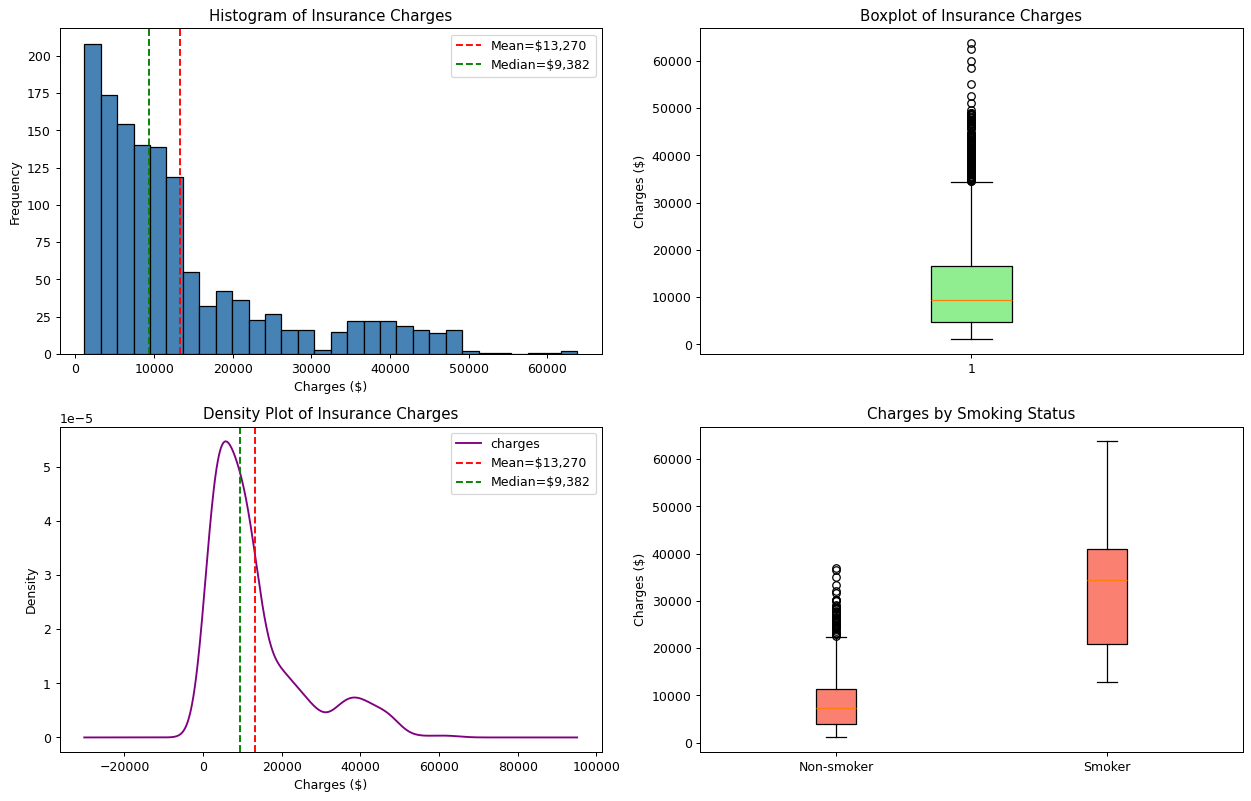

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histogram
axes[0, 0].hist(df['charges'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].axvline(mean_charges, color='red', linestyle='--', label=f'Mean=${mean_charges:,.0f}')
axes[0, 0].axvline(median_charges, color='green', linestyle='--', label=f'Median=${median_charges:,.0f}')
axes[0, 0].set_title('Histogram of Insurance Charges')
axes[0, 0].set_xlabel('Charges ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Boxplot (overall)
axes[0, 1].boxplot(df['charges'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
axes[0, 1].set_title('Boxplot of Insurance Charges')
axes[0, 1].set_ylabel('Charges ($)')

# Density plot (KDE)
df['charges'].plot(kind='density', ax=axes[1, 0], color='purple')
axes[1, 0].axvline(mean_charges, color='red', linestyle='--', label=f'Mean=${mean_charges:,.0f}')
axes[1, 0].axvline(median_charges, color='green', linestyle='--', label=f'Median=${median_charges:,.0f}')
axes[1, 0].set_title('Density Plot of Insurance Charges')
axes[1, 0].set_xlabel('Charges ($)')
axes[1, 0].legend()

# Boxplot split by smoker status
smoker_groups = [df.loc[df['smoker'] == 'no', 'charges'], df.loc[df['smoker'] == 'yes', 'charges']]
axes[1, 1].boxplot(smoker_groups, tick_labels=['Non-smoker', 'Smoker'], patch_artist=True,
                    boxprops=dict(facecolor='salmon'))
axes[1, 1].set_title('Charges by Smoking Status')
axes[1, 1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()


**Interpretation:**
- The **histogram** is clearly right-skewed: a tall peak of lower charges (under ~\$15,000)
  with a long tail stretching out toward \$60,000+.
- The **overall boxplot** shows many points above the upper whisker — the statistical
  outliers we detected using the IQR rule.
- The **density plot** confirms a bimodal-ish, right-skewed shape, with the mean visibly
  pulled to the right of the median.
- The **smoker-split boxplot** makes the underlying cause obvious: **smokers** have a much
  higher median and far higher spread of charges than non-smokers — this is the real-world
  driver behind the skew and outliers seen in the overall distribution.


## 8. Pivot Tables

A **pivot table** summarizes data by grouping it along one or more categorical variables and
aggregating a numeric variable. Here we summarize average `charges` by `smoker` status and
`region`, and add BMI/age context.


In [9]:
# Pivot table: average charges by region and smoking status
pivot1 = pd.pivot_table(df, values='charges', index='region', columns='smoker',
                         aggfunc='mean').round(2)
print("Average charges ($) by Region and Smoking status:\n")
pivot1


Average charges ($) by Region and Smoking status:



smoker,no,yes
region,,
northeast,9165.53,29673.54
northwest,8556.46,30192.00
southeast,8032.22,34845.00
southwest,8019.28,32269.06


In [10]:
# Pivot table with multiple aggregations across multiple numeric columns, by sex and smoker
pivot2 = pd.pivot_table(
    df,
    values=['charges', 'bmi', 'age'],
    index=['sex', 'smoker'],
    aggfunc={'charges': ['mean', 'median'], 'bmi': 'mean', 'age': 'mean'}
).round(2)
print("Summary statistics by Sex and Smoking status:\n")
pivot2


Summary statistics by Sex and Smoking status:



age    bmi   charges          
                mean   mean      mean    median
sex    smoker                                  
female no      39.69  30.54   8762.30   7639.42
       yes     38.61  29.61  30679.00  28950.47
male   no      39.06  30.77   8087.20   6985.51
       yes     38.45  31.50  33042.01  36085.22

**Interpretation:** The pivot tables let us compare average charges across subgroups
without writing manual `groupby` loops. Across every region, **smokers pay 3-4x more on
average** than non-smokers, and this pattern holds consistently for both sexes — reinforcing
that `smoker` is the dominant real-world risk factor behind medical insurance charges in
this dataset.


## 9. Conclusion

Using the real-world **Medical Cost Personal Dataset** (1,338 records), we:
- Framed a clear **problem statement** around what drives real insurance charges.
- **Loaded** a real dataset into a pandas DataFrame.
- Identified **dependent vs independent variables** (`charges` vs age/bmi/children/sex/smoker/region).
- Compared **mean vs median** and found a right-skewed distribution.
- Compared **variance vs IQR** and traced the extra spread to smoker-driven outliers.
- Computed **skewness** to numerically confirm the right-skewed shape.
- Visualized the distribution using a **histogram, boxplot, and density plot**.
- Summarized subgroup performance using **pivot tables**, revealing smoking status as the
  strongest real-world cost driver.

Together, these steps form the core of **descriptive/exploratory data analysis (EDA)** on
real-world data — the essential first step before building any predictive model for
insurance premium pricing.
